# 🎨 이미지 생성 AI 기법 이해하기 — 중간 과정 시각화 버전

**실행 환경:** Google Colab (GPU 권장)

## ⚙️ 환경 설정

In [2]:
# !pip install torch torchvision matplotlib numpy -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 중인 장치: {device}')

!apt-get -qq install fonts-nanum
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('환경 설정 완료! ✅')

사용 중인 장치: cuda
환경 설정 완료! ✅


## 📦 데이터 로드

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.69MB/s]


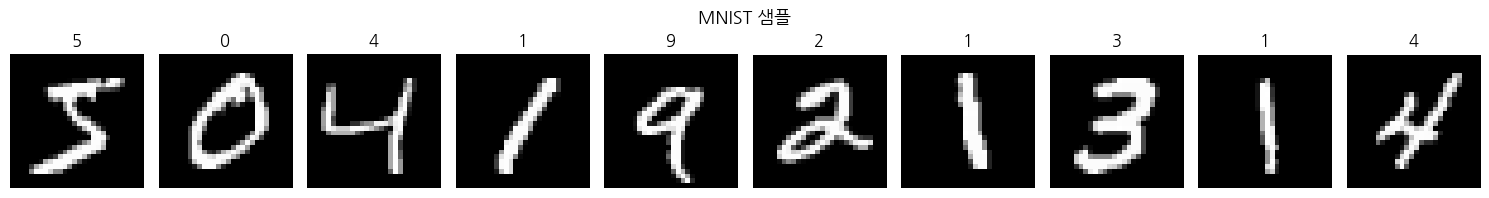

학습 데이터: 60,000장


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True
)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'{label}')
    ax.axis('off')
plt.suptitle('MNIST 샘플', fontsize=13)
plt.tight_layout()
plt.show()
print(f'학습 데이터: {len(train_dataset):,}장')

---
# 1️⃣ 오토인코더 (Autoencoder)

```
원본(28×28) → [인코더 레이어1] → [레이어2] → [레이어3] → 잠재벡터(16) → [디코더 레이어1] → [레이어2] → [레이어3] → 복원(28×28)
```
각 레이어를 통과할 때마다 데이터가 어떻게 변하는지 확인합니다.

In [4]:
# 오토인코더 모델 — 중간 출력을 추출할 수 있도록 레이어를 분리

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # 인코더 레이어들을 개별 정의 (중간 결과 추출용)
        self.enc1 = nn.Linear(784, 128)
        self.enc2 = nn.Linear(128, 64)
        self.enc3 = nn.Linear(64, 16)

        # 디코더 레이어들
        self.dec1 = nn.Linear(16, 64)
        self.dec2 = nn.Linear(64, 128)
        self.dec3 = nn.Linear(128, 784)

    def encode_with_intermediates(self, x):
        """인코더 중간 출력을 모두 반환"""
        x = x.view(-1, 784)
        h1 = F.relu(self.enc1(x))
        h2 = F.relu(self.enc2(h1))
        z = self.enc3(h2)
        return z, [x, h1, h2, z]

    def decode_with_intermediates(self, z):
        """디코더 중간 출력을 모두 반환"""
        h1 = F.relu(self.dec1(z))
        h2 = F.relu(self.dec2(h1))
        out = torch.tanh(self.dec3(h2))
        return out.view(-1, 1, 28, 28), [z, h1, h2, out]

    def forward(self, x):
        z, _ = self.encode_with_intermediates(x)
        recon, _ = self.decode_with_intermediates(z)
        return recon

ae_model = Autoencoder().to(device)
print('오토인코더 생성 완료 ✅')
print(f'파라미터 수: {sum(p.numel() for p in ae_model.parameters()):,}개')

오토인코더 생성 완료 ✅
파라미터 수: 220,320개


In [5]:
# 오토인코더 학습

ae_optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
ae_losses = []

print('오토인코더 학습 시작...')
for epoch in range(10):
    total_loss = 0
    for batch_imgs, _ in train_loader:
        batch_imgs = batch_imgs.to(device)
        reconstructed = ae_model(batch_imgs)
        loss = criterion(reconstructed, batch_imgs)
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    ae_losses.append(avg_loss)
    print(f'  에폭 {epoch+1:2d}/10 | 손실: {avg_loss:.4f}')
print('\n학습 완료! ✅')

오토인코더 학습 시작...
  에폭  1/10 | 손실: 0.1839
  에폭  2/10 | 손실: 0.0912
  에폭  3/10 | 손실: 0.0780
  에폭  4/10 | 손실: 0.0720
  에폭  5/10 | 손실: 0.0675
  에폭  6/10 | 손실: 0.0640
  에폭  7/10 | 손실: 0.0611
  에폭  8/10 | 손실: 0.0591
  에폭  9/10 | 손실: 0.0573
  에폭 10/10 | 손실: 0.0559

학습 완료! ✅


### 🔍 오토인코더 중간 과정 시각화
입력 이미지가 인코더를 거쳐 16개 숫자(잠재 벡터)로 압축되고, 디코더가 이를 다시 이미지로 복원하는 전 과정을 봅니다.

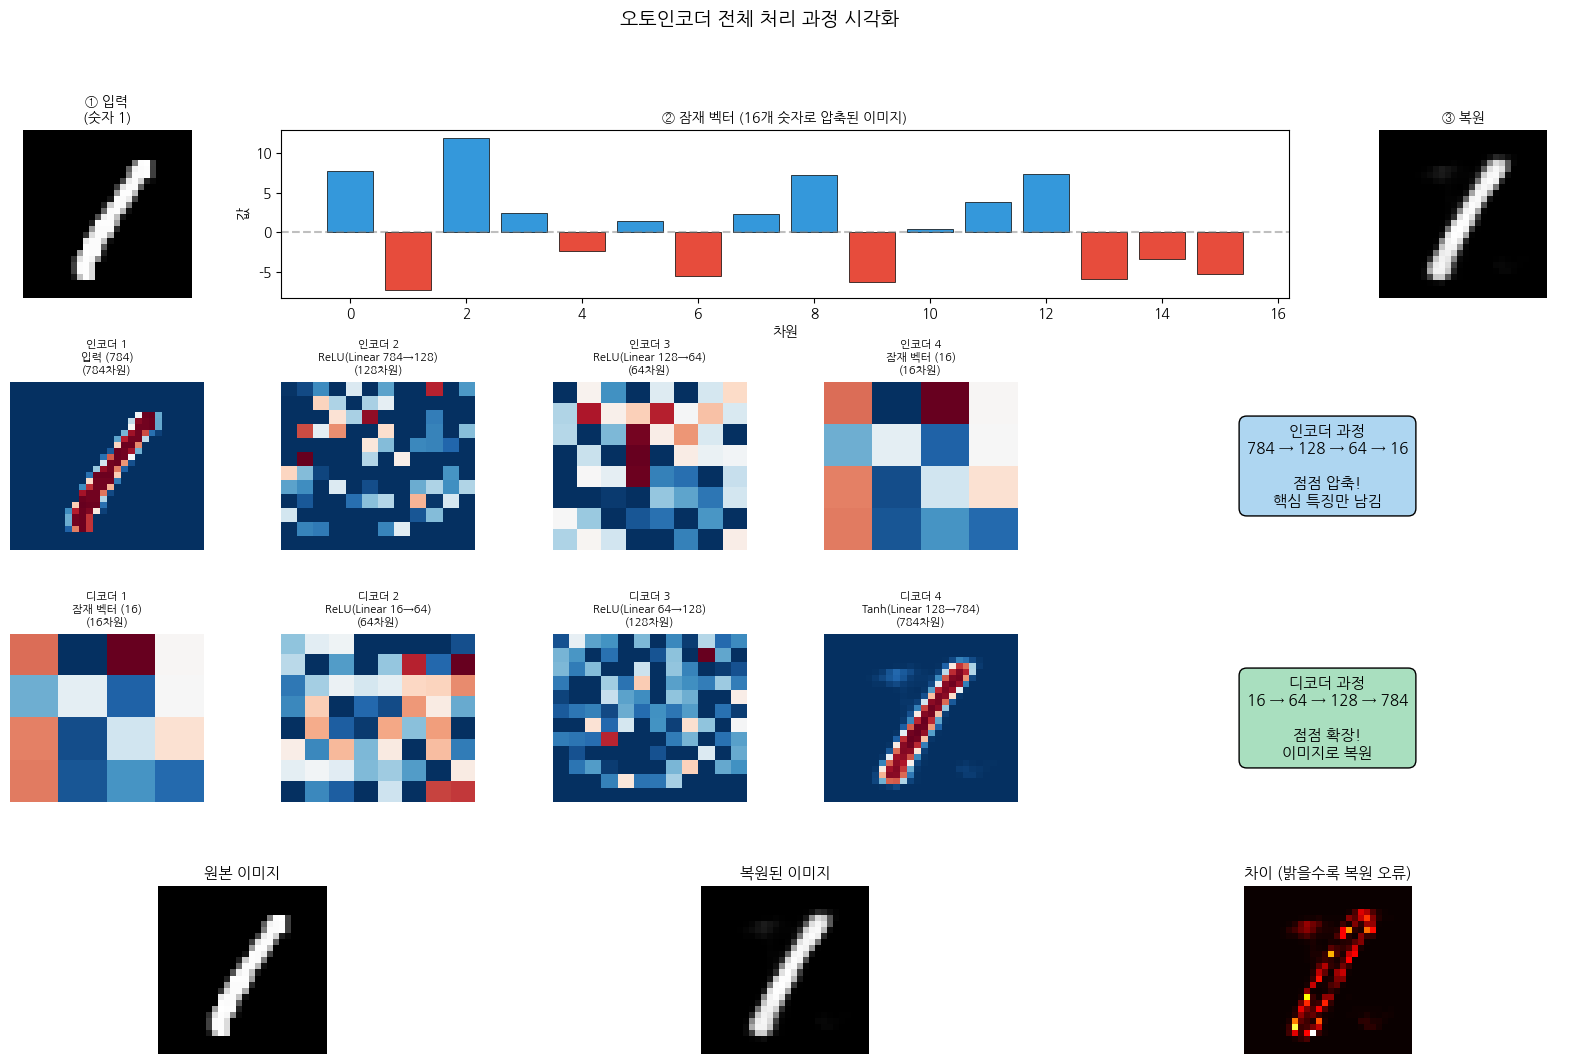

In [6]:
# 오토인코더 중간 과정 시각화

ae_model.eval()
sample_img, label = train_dataset[3]
sample_img = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    z, enc_intermediates = ae_model.encode_with_intermediates(sample_img)
    recon, dec_intermediates = ae_model.decode_with_intermediates(z)

# enc_intermediates: [input(784), h1(128), h2(64), z(16)]
# dec_intermediates: [z(16), h1(64), h2(128), out(784)]

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(4, 6, hspace=0.5, wspace=0.4)

# --- 상단: 전체 흐름 요약 ---
ax_input = fig.add_subplot(gs[0, 0])
ax_input.imshow(sample_img.cpu().squeeze(), cmap='gray')
ax_input.set_title(f'① 입력\n(숫자 {label})', fontsize=10, fontweight='bold')
ax_input.axis('off')

ax_latent = fig.add_subplot(gs[0, 1:5])
z_np = z.cpu().squeeze().numpy()
colors = ['#e74c3c' if v < 0 else '#3498db' for v in z_np]
ax_latent.bar(range(16), z_np, color=colors, edgecolor='black', linewidth=0.5)
ax_latent.set_title('② 잠재 벡터 (16개 숫자로 압축된 이미지)', fontsize=10, fontweight='bold')
ax_latent.set_xlabel('차원')
ax_latent.set_ylabel('값')
ax_latent.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

ax_output = fig.add_subplot(gs[0, 5])
ax_output.imshow(recon.cpu().squeeze(), cmap='gray')
ax_output.set_title('③ 복원', fontsize=10, fontweight='bold')
ax_output.axis('off')

# --- 중단: 인코더 각 레이어 활성화 ---
layer_names_enc = ['입력 (784)', 'ReLU(Linear 784→128)', 'ReLU(Linear 128→64)', '잠재 벡터 (16)']
for i, (name, h) in enumerate(zip(layer_names_enc, enc_intermediates)):
    ax = fig.add_subplot(gs[1, i] if i < 4 else gs[1, i])
    h_np = h.cpu().squeeze().numpy()
    # 히트맵으로 표시 (적절한 크기로 reshape)
    side = int(np.ceil(np.sqrt(len(h_np))))
    padded = np.zeros(side * side)
    padded[:len(h_np)] = h_np
    ax.imshow(padded.reshape(side, side), cmap='RdBu_r', aspect='auto')
    ax.set_title(f'인코더 {i+1}\n{name}\n({len(h_np)}차원)', fontsize=8)
    ax.axis('off')

# 화살표 텍스트
ax_arrow1 = fig.add_subplot(gs[1, 4:])
ax_arrow1.text(0.5, 0.5, '인코더 과정\n784 → 128 → 64 → 16\n\n점점 압축!\n핵심 특징만 남김',
               ha='center', va='center', fontsize=11,
               bbox=dict(boxstyle='round,pad=0.5', facecolor='#AED6F1'))
ax_arrow1.axis('off')

# --- 하단: 디코더 각 레이어 활성화 ---
layer_names_dec = ['잠재 벡터 (16)', 'ReLU(Linear 16→64)', 'ReLU(Linear 64→128)', 'Tanh(Linear 128→784)']
for i, (name, h) in enumerate(zip(layer_names_dec, dec_intermediates)):
    ax = fig.add_subplot(gs[2, i])
    h_np = h.cpu().squeeze().numpy()
    side = int(np.ceil(np.sqrt(len(h_np))))
    padded = np.zeros(side * side)
    padded[:len(h_np)] = h_np
    ax.imshow(padded.reshape(side, side), cmap='RdBu_r', aspect='auto')
    ax.set_title(f'디코더 {i+1}\n{name}\n({len(h_np)}차원)', fontsize=8)
    ax.axis('off')

ax_arrow2 = fig.add_subplot(gs[2, 4:])
ax_arrow2.text(0.5, 0.5, '디코더 과정\n16 → 64 → 128 → 784\n\n점점 확장!\n이미지로 복원',
               ha='center', va='center', fontsize=11,
               bbox=dict(boxstyle='round,pad=0.5', facecolor='#A9DFBF'))
ax_arrow2.axis('off')

# --- 최하단: 디코더 출력을 이미지로 reshape하여 복원 과정 시각화 ---
ax_compare = fig.add_subplot(gs[3, :2])
ax_compare.imshow(sample_img.cpu().squeeze(), cmap='gray')
ax_compare.set_title('원본 이미지', fontsize=11)
ax_compare.axis('off')

ax_recon = fig.add_subplot(gs[3, 2:4])
ax_recon.imshow(recon.cpu().squeeze(), cmap='gray')
ax_recon.set_title('복원된 이미지', fontsize=11)
ax_recon.axis('off')

ax_diff = fig.add_subplot(gs[3, 4:])
diff = (sample_img - recon).abs().cpu().squeeze()
ax_diff.imshow(diff, cmap='hot')
ax_diff.set_title('차이 (밝을수록 복원 오류)', fontsize=11)
ax_diff.axis('off')

plt.suptitle('오토인코더 전체 처리 과정 시각화', fontsize=14, fontweight='bold')
plt.show()

### 🔍 여러 숫자의 잠재 벡터 비교
같은 숫자는 비슷한 잠재 벡터를, 다른 숫자는 다른 잠재 벡터를 가지는지 확인합니다.

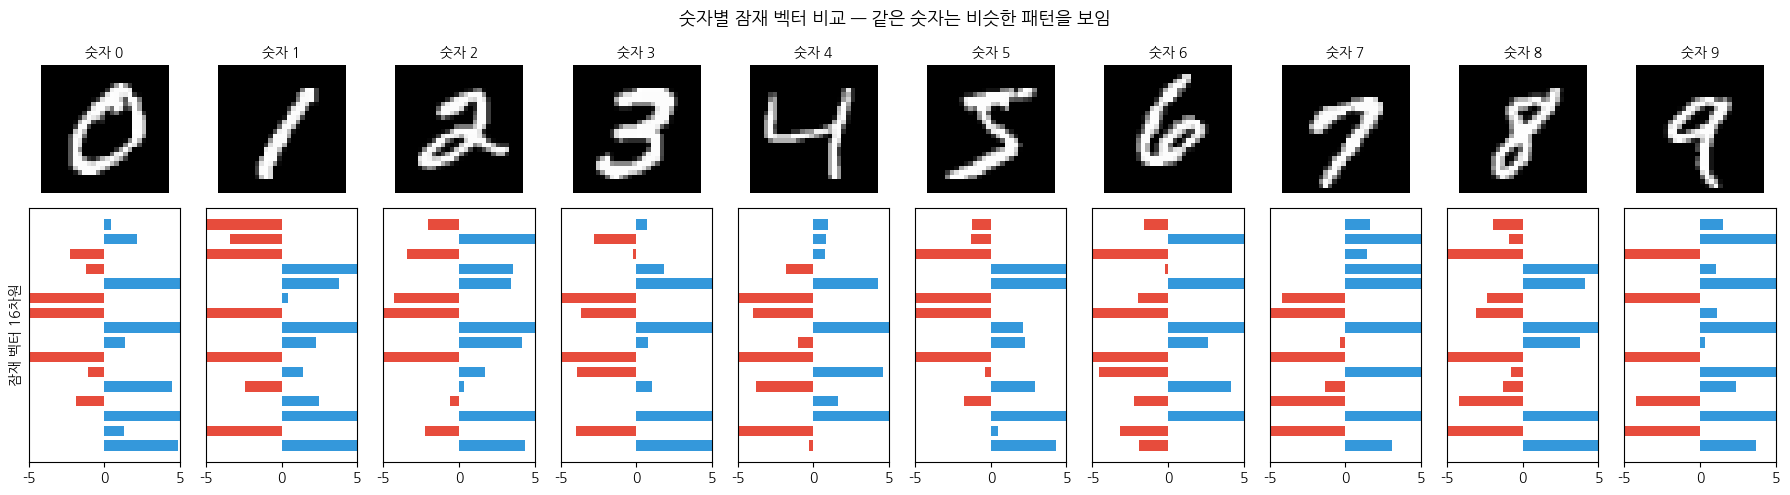

✅ 오토인코더는 각 숫자를 고유한 16차원 "코드"로 압축합니다!


In [7]:
# 여러 숫자의 잠재벡터 비교

ae_model.eval()
fig, axes = plt.subplots(2, 10, figsize=(18, 5), gridspec_kw={'height_ratios': [1, 2]})

for i in range(10):
    # 각 숫자(0~9)의 샘플 찾기
    for img, lbl in train_dataset:
        if lbl == i:
            break
    img = img.unsqueeze(0).to(device)
    with torch.no_grad():
        z, _ = ae_model.encode_with_intermediates(img)

    axes[0, i].imshow(img.cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'숫자 {i}', fontsize=10)
    axes[0, i].axis('off')

    z_np = z.cpu().squeeze().numpy()
    colors = ['#e74c3c' if v < 0 else '#3498db' for v in z_np]
    axes[1, i].barh(range(16), z_np, color=colors, height=0.7)
    axes[1, i].set_xlim(-5, 5)
    axes[1, i].set_yticks([])
    if i == 0:
        axes[1, i].set_ylabel('잠재 벡터 16차원')

plt.suptitle('숫자별 잠재 벡터 비교 — 같은 숫자는 비슷한 패턴을 보임', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ 오토인코더는 각 숫자를 고유한 16차원 "코드"로 압축합니다!')

---
# 2️⃣ 변분 오토인코더 (VAE)

```
이미지 → [인코더] → 평균(μ) + 분산(σ²) → 샘플링(z) → [디코더] → 복원/생성
```
오토인코더와 달리 잠재 공간이 **확률 분포**이므로, 분포에서 샘플링하여 새 이미지를 생성할 수 있습니다.

In [8]:
class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        self.enc1 = nn.Linear(784, 256)
        self.enc2 = nn.Linear(256, 128)
        self.fc_mean = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.dec1 = nn.Linear(latent_dim, 128)
        self.dec2 = nn.Linear(128, 256)
        self.dec3 = nn.Linear(256, 784)

    def encode(self, x):
        x = x.view(-1, 784)
        h = F.relu(self.enc1(x))
        h = F.relu(self.enc2(h))
        return self.fc_mean(h), self.fc_logvar(h)

    def reparameterize(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std

    def decode(self, z):
        h = F.relu(self.dec1(z))
        h = F.relu(self.dec2(h))
        return torch.tanh(self.dec3(h)).view(-1, 1, 28, 28)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        return self.decode(z), mean, logvar

vae_model = VAE(latent_dim=16).to(device)
print('VAE 모델 생성 완료 ✅')

VAE 모델 생성 완료 ✅


In [20]:
# VAE 학습

def vae_loss(reconstructed, original, mean, logvar, beta):
    recon_loss = F.mse_loss(reconstructed, original, reduction='sum') / original.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp()) / original.size(0)
    return recon_loss + beta * kl_loss

vae_optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)
vae_losses = []

print('VAE 학습 시작...')
for epoch in range(10):
    beta = min(0.05, epoch / 10.0 * 0.15)  # 최종값 0.15
    total_loss = 0
    for batch_imgs, _ in train_loader:
        batch_imgs = batch_imgs.to(device)
        reconstructed, mean, logvar = vae_model(batch_imgs)
        loss = vae_loss(reconstructed, batch_imgs, mean, logvar, beta)
        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f'  에폭 {epoch+1:2d}/10 | β={beta:.2f} | 손실: {avg_loss:.4f}')

VAE 학습 시작...
  에폭  1/10 | β=0.00 | 손실: 51.5080
  에폭  2/10 | β=0.01 | 손실: 51.7070
  에폭  3/10 | β=0.03 | 손실: 51.9148
  에폭  4/10 | β=0.04 | 손실: 51.8323
  에폭  5/10 | β=0.05 | 손실: 51.0777
  에폭  6/10 | β=0.05 | 손실: 50.2466
  에폭  7/10 | β=0.05 | 손실: 49.5425
  에폭  8/10 | β=0.05 | 손실: 49.1176
  에폭  9/10 | β=0.05 | 손실: 48.5457
  에폭 10/10 | β=0.05 | 손실: 48.2349


### 🔍 VAE 잠재 공간 탐험: 두 숫자 사이를 보간(interpolation)

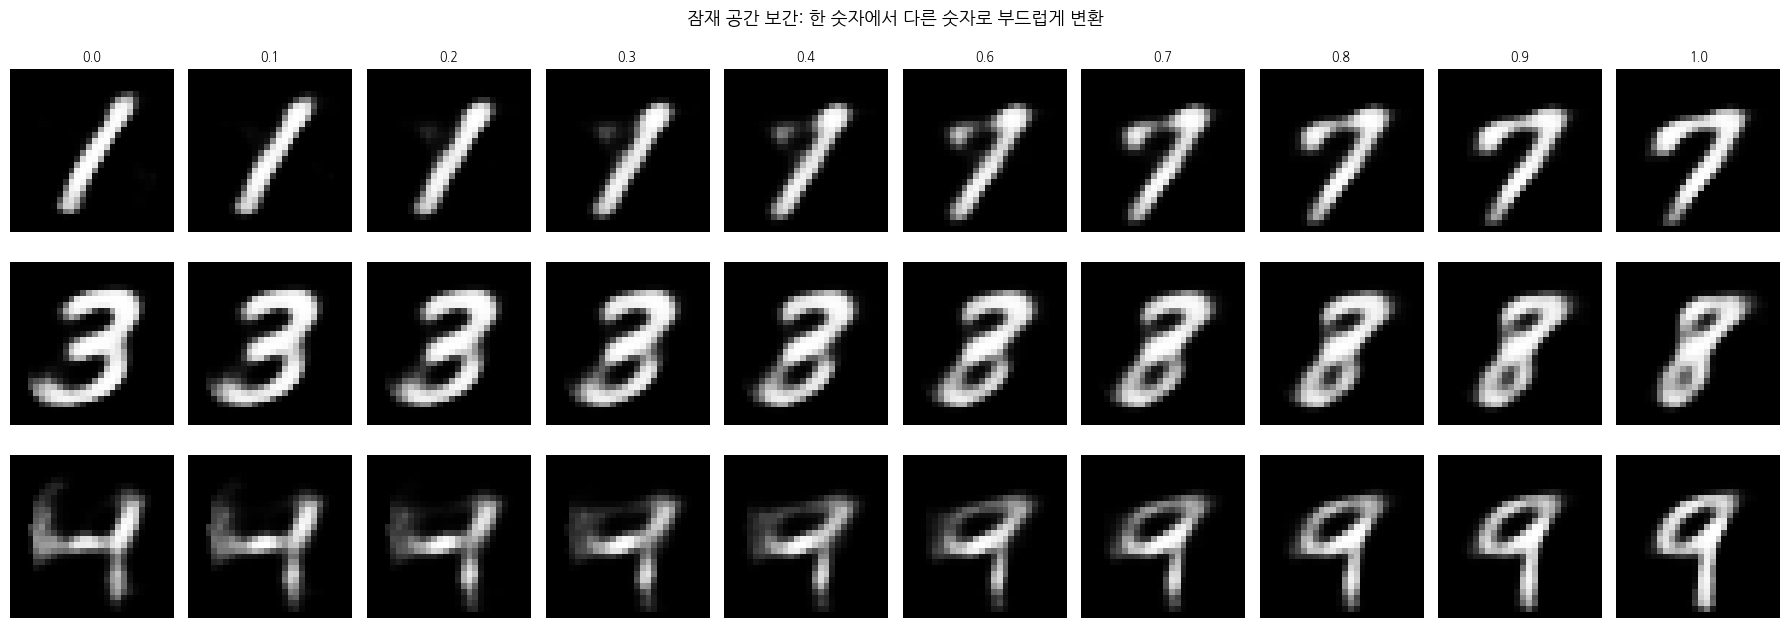

✅ 잠재 공간이 연속적이므로, 숫자 사이를 자연스럽게 이동할 수 있습니다!


In [22]:
# 잠재 공간 보간: 숫자 A → 숫자 B로 서서히 변화

vae_model.eval()

# 두 숫자 선택
def find_digit(dataset, digit):
    for img, lbl in dataset:
        if lbl == digit:
            return img.unsqueeze(0).to(device)

pairs = [(1, 7), (3, 8), (4, 9)]
fig, axes = plt.subplots(len(pairs), 10, figsize=(18, len(pairs)*2.2))

for row, (d1, d2) in enumerate(pairs):
    img1 = find_digit(train_dataset, d1)
    img2 = find_digit(train_dataset, d2)

    with torch.no_grad():
        mean1, _ = vae_model.encode(img1)
        mean2, _ = vae_model.encode(img2)

        for i, alpha in enumerate(np.linspace(0, 1, 10)):
            z_interp = mean1 * (1 - alpha) + mean2 * alpha
            img_interp = vae_model.decode(z_interp)
            axes[row, i].imshow(img_interp.cpu().squeeze(), cmap='gray')
            axes[row, i].axis('off')
            if row == 0:
                axes[row, i].set_title(f'{alpha:.1f}', fontsize=9)

    axes[row, 0].set_ylabel(f'{d1}→{d2}', fontsize=12, rotation=0, labelpad=30)

plt.suptitle('잠재 공간 보간: 한 숫자에서 다른 숫자로 부드럽게 변환', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ 잠재 공간이 연속적이므로, 숫자 사이를 자연스럽게 이동할 수 있습니다!')

---
# 3️⃣ GAN (Generative Adversarial Network)

```
랜덤 노이즈(100) → [생성자 레이어1] → [레이어2] → [레이어3] → 가짜 이미지(784)
                                                                    ↓
                                                              [판별자] → 진짜/가짜?
```

In [23]:
LATENT_DIM = 100

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(LATENT_DIM, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.fc3 = nn.Linear(512, 784)

    def forward(self, z):
        h1 = F.leaky_relu(self.bn1(self.fc1(z)), 0.2)
        h2 = F.leaky_relu(self.bn2(self.fc2(h1)), 0.2)
        out = torch.tanh(self.fc3(h2))
        return out.view(-1, 1, 28, 28)

    def forward_with_intermediates(self, z):
        h1 = F.leaky_relu(self.bn1(self.fc1(z)), 0.2)
        h2 = F.leaky_relu(self.bn2(self.fc2(h1)), 0.2)
        out = torch.tanh(self.fc3(h2))
        return out.view(-1, 1, 28, 28), [z, h1, h2, out]

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 1)

    def forward(self, img):
        x = img.view(-1, 784)
        h1 = F.leaky_relu(self.fc1(x), 0.2)
        h2 = F.leaky_relu(self.fc2(h1), 0.2)
        return torch.sigmoid(self.fc3(h2))

G = Generator().to(device)
D = Discriminator().to(device)
print('GAN 모델 생성 완료 ✅')

GAN 모델 생성 완료 ✅


In [24]:
# GAN 학습 — 에폭별 생성 결과도 저장

criterion = nn.BCELoss()
g_optimizer = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_optimizer = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

fixed_noise = torch.randn(16, LATENT_DIM).to(device)
g_losses, d_losses = [], []
epoch_samples = {}  # 에폭별 생성 이미지 저장

print('GAN 학습 시작...')
for epoch in range(20):
    g_total, d_total = 0, 0
    for batch_imgs, _ in train_loader:
        batch_size = batch_imgs.size(0)
        real_imgs = batch_imgs.to(device)
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # D 학습
        z = torch.randn(batch_size, LATENT_DIM).to(device)
        fake_imgs = G(z).detach()
        d_loss = criterion(D(real_imgs), real_labels) + criterion(D(fake_imgs), fake_labels)
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # G 학습
        z = torch.randn(batch_size, LATENT_DIM).to(device)
        fake_imgs = G(z)
        g_loss = criterion(D(fake_imgs), real_labels)
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        g_total += g_loss.item()
        d_total += d_loss.item()

    g_avg = g_total / len(train_loader)
    d_avg = d_total / len(train_loader)
    g_losses.append(g_avg)
    d_losses.append(d_avg)

    # 에폭별 생성 이미지 스냅샷 저장
    if (epoch + 1) in [1, 5, 10, 15, 20]:
        G.eval()
        with torch.no_grad():
            epoch_samples[epoch+1] = G(fixed_noise).cpu()
        G.train()

    if (epoch + 1) % 5 == 0:
        print(f'  에폭 {epoch+1:2d}/20 | G: {g_avg:.4f} | D: {d_avg:.4f}')

print('\n학습 완료! ✅')

GAN 학습 시작...
  에폭  5/20 | G: 1.3461 | D: 1.0191
  에폭 10/20 | G: 1.2567 | D: 1.0637
  에폭 15/20 | G: 1.1417 | D: 1.1187
  에폭 20/20 | G: 1.0969 | D: 1.1453

학습 완료! ✅


### 🔍 GAN 중간 과정 시각화
1. 생성자 내부: 노이즈가 레이어를 거치며 이미지가 되는 과정
2. 판별자의 판단: 진짜 vs 가짜에 대한 점수
3. 학습 진행: 에폭별 생성 품질 변화

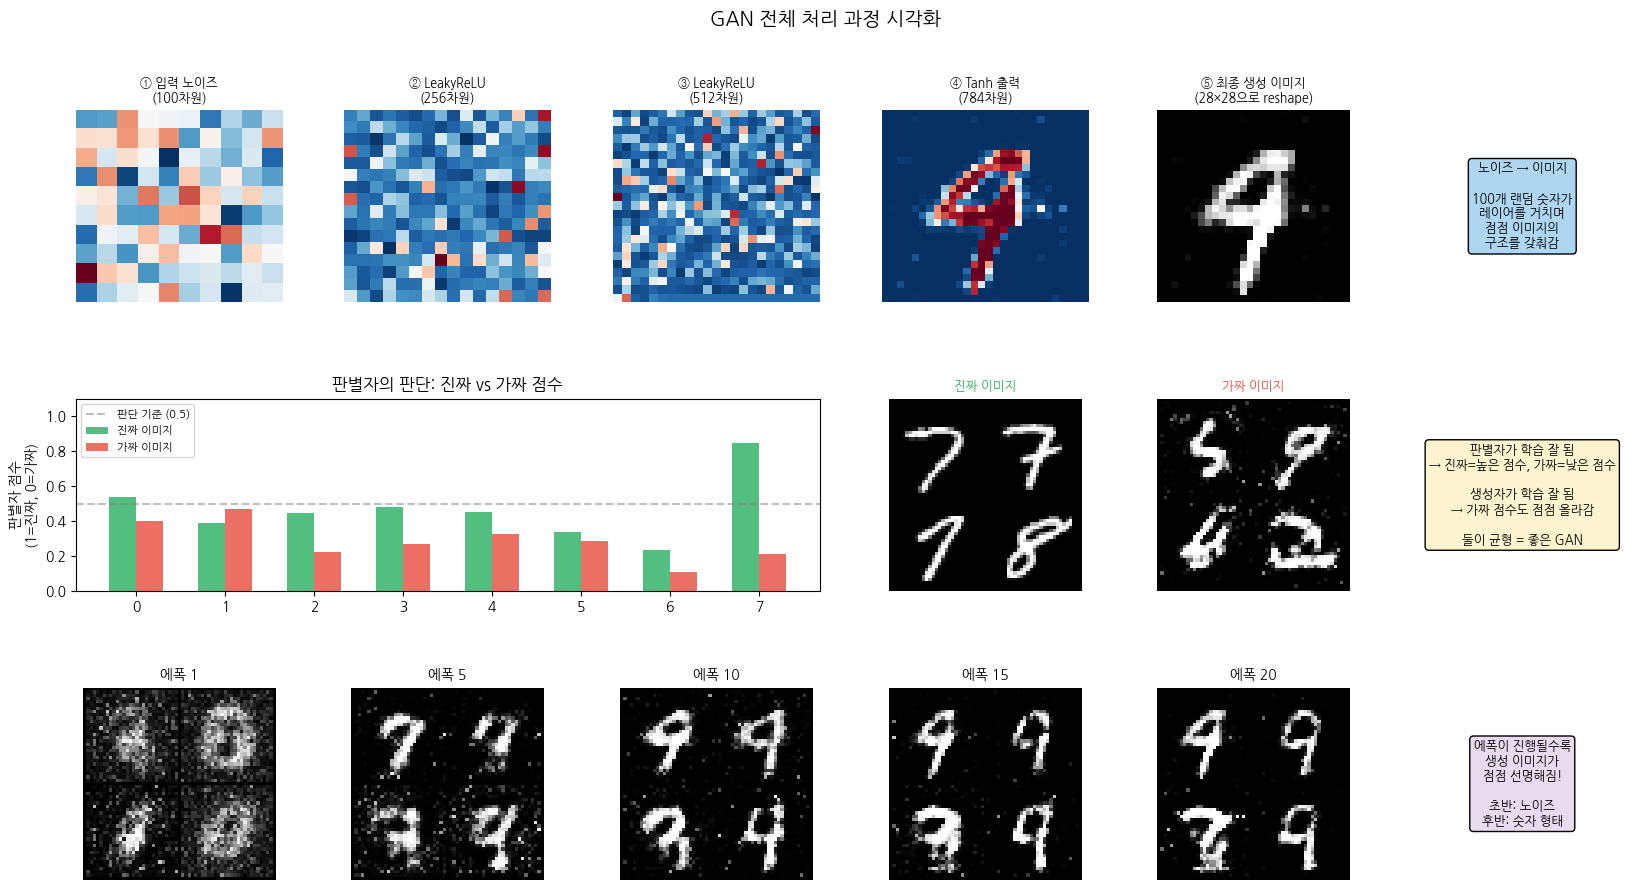

In [28]:
# GAN 생성자 내부 과정 시각화

G.eval()

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(3, 6, hspace=0.5, wspace=0.3)

# --- Row 0: 생성자 레이어별 출력 ---
z_single = fixed_noise[0:1]
with torch.no_grad():
    output, intermediates = G.forward_with_intermediates(z_single)
    # intermediates: [z(100), h1(256), h2(512), out(784)]

layer_names = ['① 입력 노이즈\n(100차원)', '② LeakyReLU\n(256차원)', '③ LeakyReLU\n(512차원)', '④ Tanh 출력\n(784차원)']
for i, (name, h) in enumerate(zip(layer_names, intermediates)):
    ax = fig.add_subplot(gs[0, i])
    h_np = h.cpu().squeeze().numpy()
    side = int(np.ceil(np.sqrt(len(h_np))))
    padded = np.zeros(side * side)
    padded[:len(h_np)] = h_np
    ax.imshow(padded.reshape(side, side), cmap='RdBu_r', aspect='auto')
    ax.set_title(name, fontsize=9)
    ax.axis('off')

# 최종 이미지
ax = fig.add_subplot(gs[0, 4])
ax.imshow(output.cpu().squeeze(), cmap='gray')
ax.set_title('⑤ 최종 생성 이미지\n(28×28으로 reshape)', fontsize=9)
ax.axis('off')

ax = fig.add_subplot(gs[0, 5])
ax.text(0.5, 0.5, '노이즈 → 이미지\n\n100개 랜덤 숫자가\n레이어를 거치며\n점점 이미지의\n구조를 갖춰감',
        ha='center', va='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#AED6F1'))
ax.axis('off')

# --- Row 1: 판별자 점수 비교 --- 부분을 아래로 교체

ax = fig.add_subplot(gs[1, :3])
with torch.no_grad():
    real_batch, _ = next(iter(train_loader))
    real_batch = real_batch[:8].to(device)
    fake_batch = G(torch.randn(8, LATENT_DIM).to(device))

    real_scores = D(real_batch).cpu().squeeze().numpy()
    fake_scores = D(fake_batch).cpu().squeeze().numpy()

x = np.arange(8)
ax.bar(x - 0.15, real_scores, 0.3, label='진짜 이미지', color='#27ae60', alpha=0.8)
ax.bar(x + 0.15, fake_scores, 0.3, label='가짜 이미지', color='#e74c3c', alpha=0.8)
ax.axhline(y=0.5, color='gray', ls='--', alpha=0.5, label='판단 기준 (0.5)')
ax.set_ylabel('판별자 점수\n(1=진짜, 0=가짜)')
ax.set_title('판별자의 판단: 진짜 vs 가짜 점수', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.1)

# 진짜 vs 가짜 이미지 직접 비교
ax_real = fig.add_subplot(gs[1, 3])
real_grid = torchvision.utils.make_grid(real_batch[:4].cpu(), nrow=2, normalize=True, padding=1)
ax_real.imshow(real_grid.permute(1, 2, 0).numpy(), cmap='gray')
ax_real.set_title('진짜 이미지', fontsize=9, color='#27ae60', fontweight='bold')
ax_real.axis('off')

ax_fake = fig.add_subplot(gs[1, 4])
fake_grid = torchvision.utils.make_grid(fake_batch[:4].cpu(), nrow=2, normalize=True, padding=1)
ax_fake.imshow(fake_grid.permute(1, 2, 0).numpy(), cmap='gray')
ax_fake.set_title('가짜 이미지', fontsize=9, color='#e74c3c', fontweight='bold')
ax_fake.axis('off')

ax_info = fig.add_subplot(gs[1, 5])
ax_info.text(0.5, 0.5, '판별자가 학습 잘 됨\n→ 진짜=높은 점수, 가짜=낮은 점수\n\n생성자가 학습 잘 됨\n→ 가짜 점수도 점점 올라감\n\n둘이 균형 = 좋은 GAN',
             ha='center', va='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='#FCF3CF'))
ax_info.axis('off')

# --- Row 2: 에폭별 생성 진행 과정 ---
epochs_to_show = sorted(epoch_samples.keys())
for col, ep in enumerate(epochs_to_show):
    ax = fig.add_subplot(gs[2, col])
    grid = torchvision.utils.make_grid(epoch_samples[ep][:4], nrow=2, normalize=True, padding=1)
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    ax.set_title(f'에폭 {ep}', fontsize=10, fontweight='bold')
    ax.axis('off')

ax = fig.add_subplot(gs[2, 5])
ax.text(0.5, 0.5, '에폭이 진행될수록\n생성 이미지가\n점점 선명해짐!\n\n초반: 노이즈\n후반: 숫자 형태',
        ha='center', va='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#E8DAEF'))
ax.axis('off')

plt.suptitle('GAN 전체 처리 과정 시각화', fontsize=14, fontweight='bold')
plt.show()

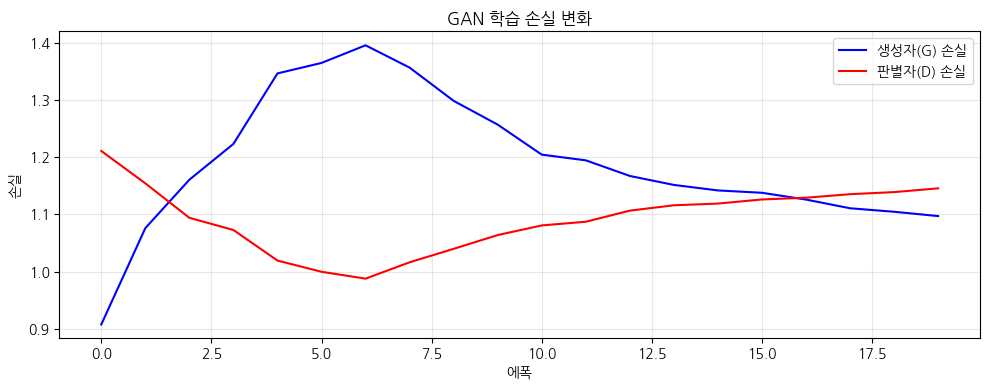

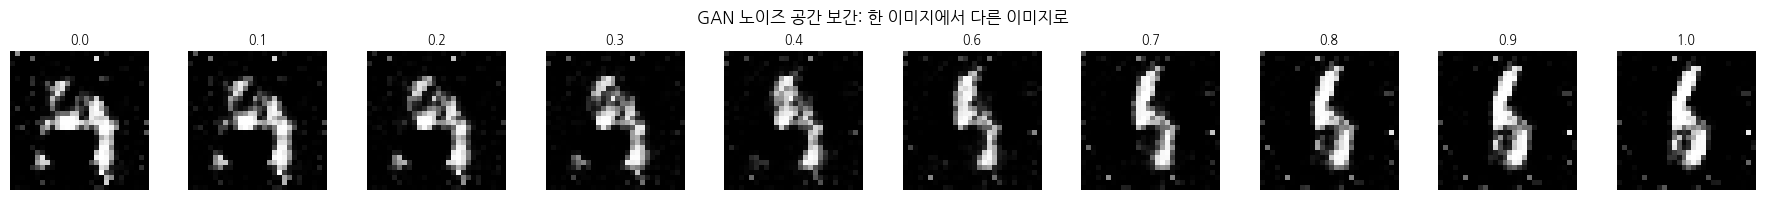

In [30]:
# 손실 그래프 + 노이즈 보간을 깔끔하게

# 1. 손실 그래프
plt.figure(figsize=(10, 4))
plt.plot(g_losses, label='생성자(G) 손실', color='blue')
plt.plot(d_losses, label='판별자(D) 손실', color='red')
plt.xlabel('에폭')
plt.ylabel('손실')
plt.title('GAN 학습 손실 변화')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. 노이즈 보간
G.eval()
z1 = torch.randn(1, LATENT_DIM).to(device)
z2 = torch.randn(1, LATENT_DIM).to(device)
fig, axes = plt.subplots(1, 10, figsize=(18, 2))
with torch.no_grad():
    for i, alpha in enumerate(np.linspace(0, 1, 10)):
        z_interp = z1 * (1 - alpha) + z2 * alpha
        img = G(z_interp)
        axes[i].imshow(img.cpu().squeeze(), cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f'{alpha:.1f}', fontsize=9)
plt.suptitle('GAN 노이즈 공간 보간: 한 이미지에서 다른 이미지로', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 4️⃣ 확산 모델 (Diffusion Model)

```
【순방향】 원본 → 약간 노이즈 → 더 노이즈 → ... → 순수 노이즈   (학습 데이터 준비)
【역방향】 순수 노이즈 → 노이즈 조금 제거 → ... → 깨끗한 이미지  (AI가 학습하는 것)
```
AI는 **"이 이미지에서 노이즈를 빼면 어떻게 될까?"**를 예측하는 법을 배웁니다.

In [31]:
# 간단한 DDPM 구현 (MNIST용)

class SimpleDiffusion:
    def __init__(self, T=300, beta_start=1e-4, beta_end=0.02):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T).to(device)
        self.alphas = 1.0 - self.betas
        self.alpha_cumprod = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, x0, t):
        """순방향: x0에 t단계만큼 노이즈 추가"""
        sqrt_alpha_cp = torch.sqrt(self.alpha_cumprod[t]).view(-1, 1, 1, 1)
        sqrt_one_minus = torch.sqrt(1 - self.alpha_cumprod[t]).view(-1, 1, 1, 1)
        noise = torch.randn_like(x0)
        return sqrt_alpha_cp * x0 + sqrt_one_minus * noise, noise

class NoisePredictor(nn.Module):
    """노이즈 예측 신경망 (간단한 U-Net 대용)"""
    def __init__(self):
        super().__init__()
        self.time_embed = nn.Embedding(300, 64)
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1),
        )
        self.time_proj = nn.Linear(64, 28*28)

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        t_proj = self.time_proj(t_emb).view(-1, 1, 28, 28)
        return self.net(x + t_proj)

diffusion = SimpleDiffusion(T=300)
noise_pred = NoisePredictor().to(device)
print('확산 모델 생성 완료 ✅')

확산 모델 생성 완료 ✅


### 🔍 순방향 과정 시각화: 노이즈가 단계적으로 추가되는 과정

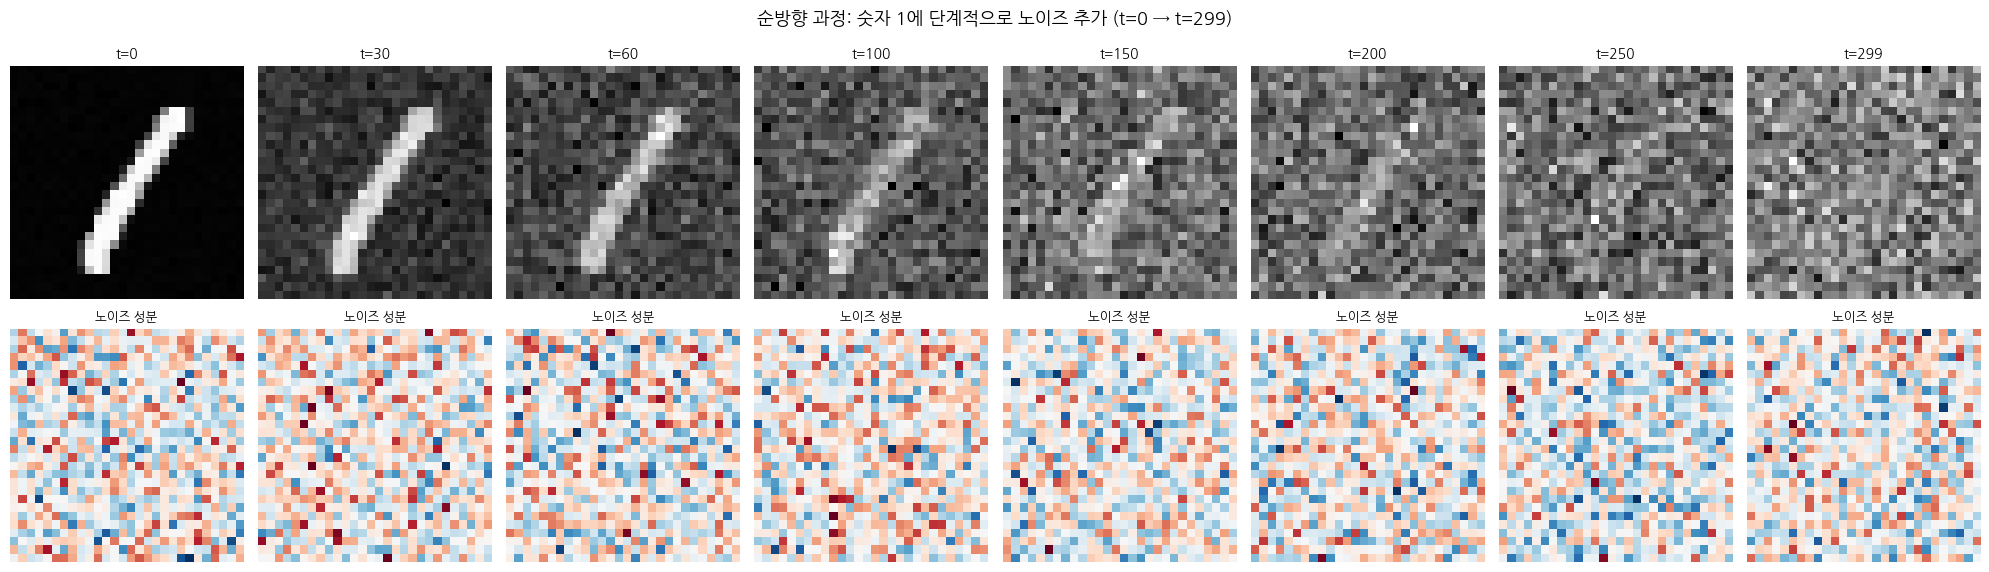

t가 커질수록 원본 정보가 사라지고 순수 노이즈에 가까워집니다.


In [32]:
# 순방향 과정: 실제 스케줄에 따른 노이즈 추가

sample_img, label = train_dataset[3]
sample_img = sample_img.unsqueeze(0).to(device)

timesteps = [0, 30, 60, 100, 150, 200, 250, 299]
fig, axes = plt.subplots(2, len(timesteps), figsize=(20, 6))

for i, t in enumerate(timesteps):
    t_tensor = torch.tensor([t]).to(device)
    noisy, noise = diffusion.add_noise(sample_img, t_tensor)

    axes[0, i].imshow(noisy.cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f't={t}', fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

    axes[1, i].imshow(noise.cpu().squeeze(), cmap='RdBu_r')
    axes[1, i].set_title(f'노이즈 성분', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('노이즈 추가된\n이미지', fontsize=10)
axes[1, 0].set_ylabel('추가된\n노이즈', fontsize=10)

plt.suptitle(f'순방향 과정: 숫자 {label}에 단계적으로 노이즈 추가 (t=0 → t=299)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('t가 커질수록 원본 정보가 사라지고 순수 노이즈에 가까워집니다.')

In [33]:
# 확산 모델 학습

diff_optimizer = optim.Adam(noise_pred.parameters(), lr=1e-3)
diff_losses = []

print('확산 모델 학습 시작...')
for epoch in range(10):
    total_loss = 0
    for batch_imgs, _ in train_loader:
        batch_imgs = batch_imgs.to(device)
        batch_size = batch_imgs.size(0)

        t = torch.randint(0, 300, (batch_size,)).to(device)
        noisy_imgs, noise = diffusion.add_noise(batch_imgs, t)

        predicted_noise = noise_pred(noisy_imgs, t)
        loss = F.mse_loss(predicted_noise, noise)

        diff_optimizer.zero_grad()
        loss.backward()
        diff_optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    diff_losses.append(avg_loss)
    print(f'  에폭 {epoch+1:2d}/10 | 손실: {avg_loss:.4f}')
print('\n학습 완료! ✅')

확산 모델 학습 시작...
  에폭  1/10 | 손실: 0.2177
  에폭  2/10 | 손실: 0.0998
  에폭  3/10 | 손실: 0.0882
  에폭  4/10 | 손실: 0.0805
  에폭  5/10 | 손실: 0.0765
  에폭  6/10 | 손실: 0.0741
  에폭  7/10 | 손실: 0.0717
  에폭  8/10 | 손실: 0.0695
  에폭  9/10 | 손실: 0.0690
  에폭 10/10 | 손실: 0.0670

학습 완료! ✅


### 🔍 역방향 과정 시각화: 노이즈에서 이미지가 복원되는 단계별 과정

역방향 과정(이미지 생성) 중...


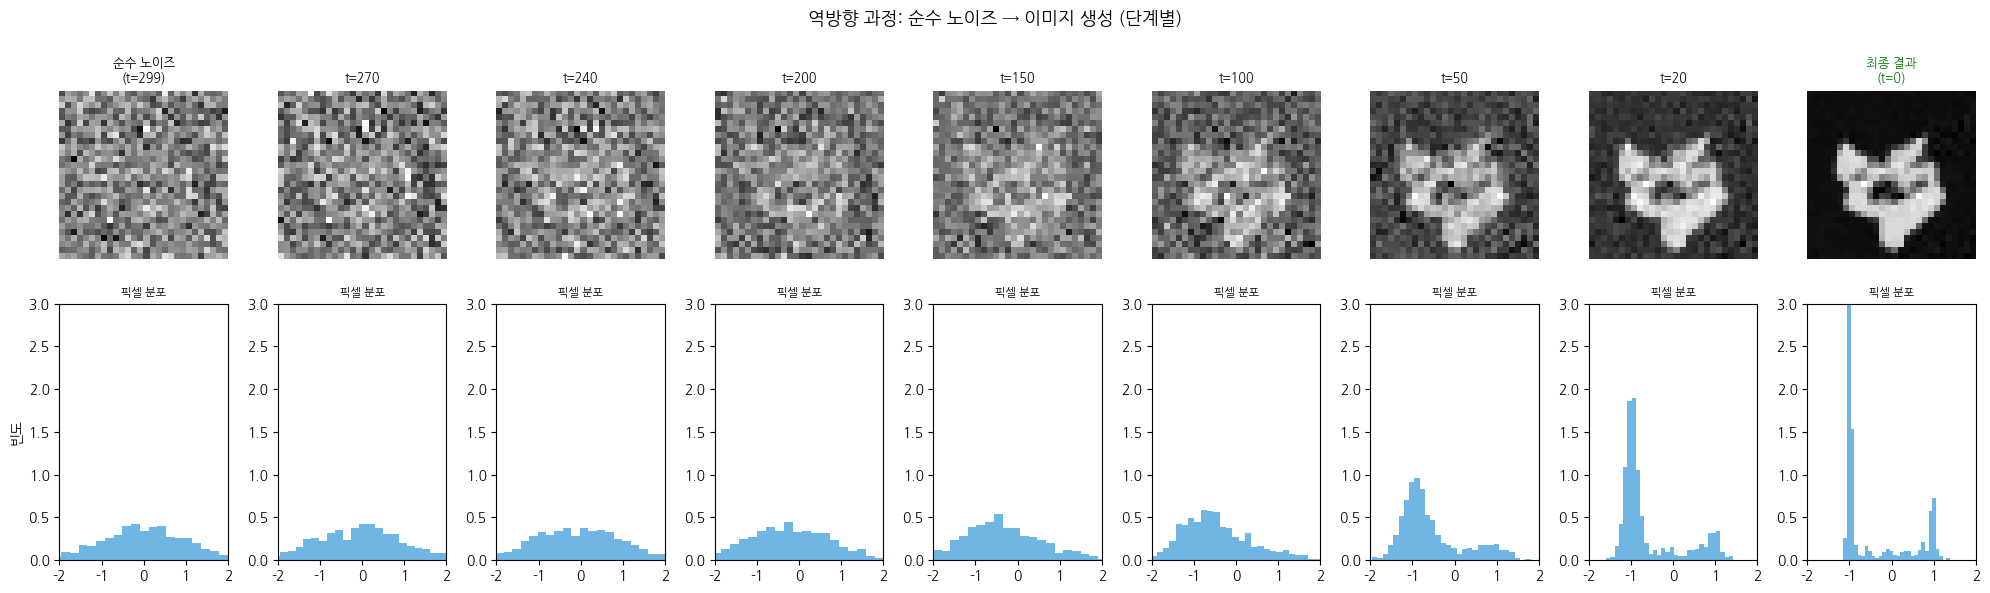

초반: 가우시안 분포 → 후반: 이미지 구조를 가진 분포로 변화
✅ AI가 매 단계에서 "이 노이즈를 어떻게 제거할까"를 예측하여 이미지를 만듭니다!


In [34]:
# 역방향 (생성) 과정 시각화

noise_pred.eval()

@torch.no_grad()
def sample_with_history(model, diffusion, shape=(1, 1, 28, 28)):
    x = torch.randn(shape).to(device)
    history = [x.cpu().squeeze().numpy()]
    timestep_history = [diffusion.T - 1]

    for t in reversed(range(diffusion.T)):
        t_tensor = torch.tensor([t]).to(device)
        predicted_noise = model(x, t_tensor)

        alpha = diffusion.alphas[t]
        alpha_cp = diffusion.alpha_cumprod[t]
        beta = diffusion.betas[t]

        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_cp)) * predicted_noise)

        if t > 0:
            x += torch.sqrt(beta) * torch.randn_like(x)

        if t in [270, 240, 200, 150, 100, 50, 20, 0]:
            history.append(x.cpu().squeeze().numpy())
            timestep_history.append(t)

    return x, history, timestep_history

print('역방향 과정(이미지 생성) 중...')
generated, history, ts = sample_with_history(noise_pred, diffusion)

fig, axes = plt.subplots(2, len(history), figsize=(20, 6))

for i, (img, t) in enumerate(zip(history, ts)):
    axes[0, i].imshow(img, cmap='gray')
    if i == 0:
        axes[0, i].set_title(f'순수 노이즈\n(t={t})', fontsize=9, fontweight='bold')
    elif i == len(history) - 1:
        axes[0, i].set_title(f'최종 결과\n(t={t})', fontsize=9, fontweight='bold', color='green')
    else:
        axes[0, i].set_title(f't={t}', fontsize=9)
    axes[0, i].axis('off')

    # 히스토그램으로 픽셀값 분포 변화
    axes[1, i].hist(img.flatten(), bins=30, color='#3498db', alpha=0.7, density=True)
    axes[1, i].set_xlim(-2, 2)
    axes[1, i].set_ylim(0, 3)
    axes[1, i].set_title('픽셀 분포', fontsize=8)
    if i == 0:
        axes[1, i].set_ylabel('빈도')

plt.suptitle('역방향 과정: 순수 노이즈 → 이미지 생성 (단계별)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('초반: 가우시안 분포 → 후반: 이미지 구조를 가진 분포로 변화')
print('✅ AI가 매 단계에서 "이 노이즈를 어떻게 제거할까"를 예측하여 이미지를 만듭니다!')

### 🔍 노이즈 예측 정확도 확인

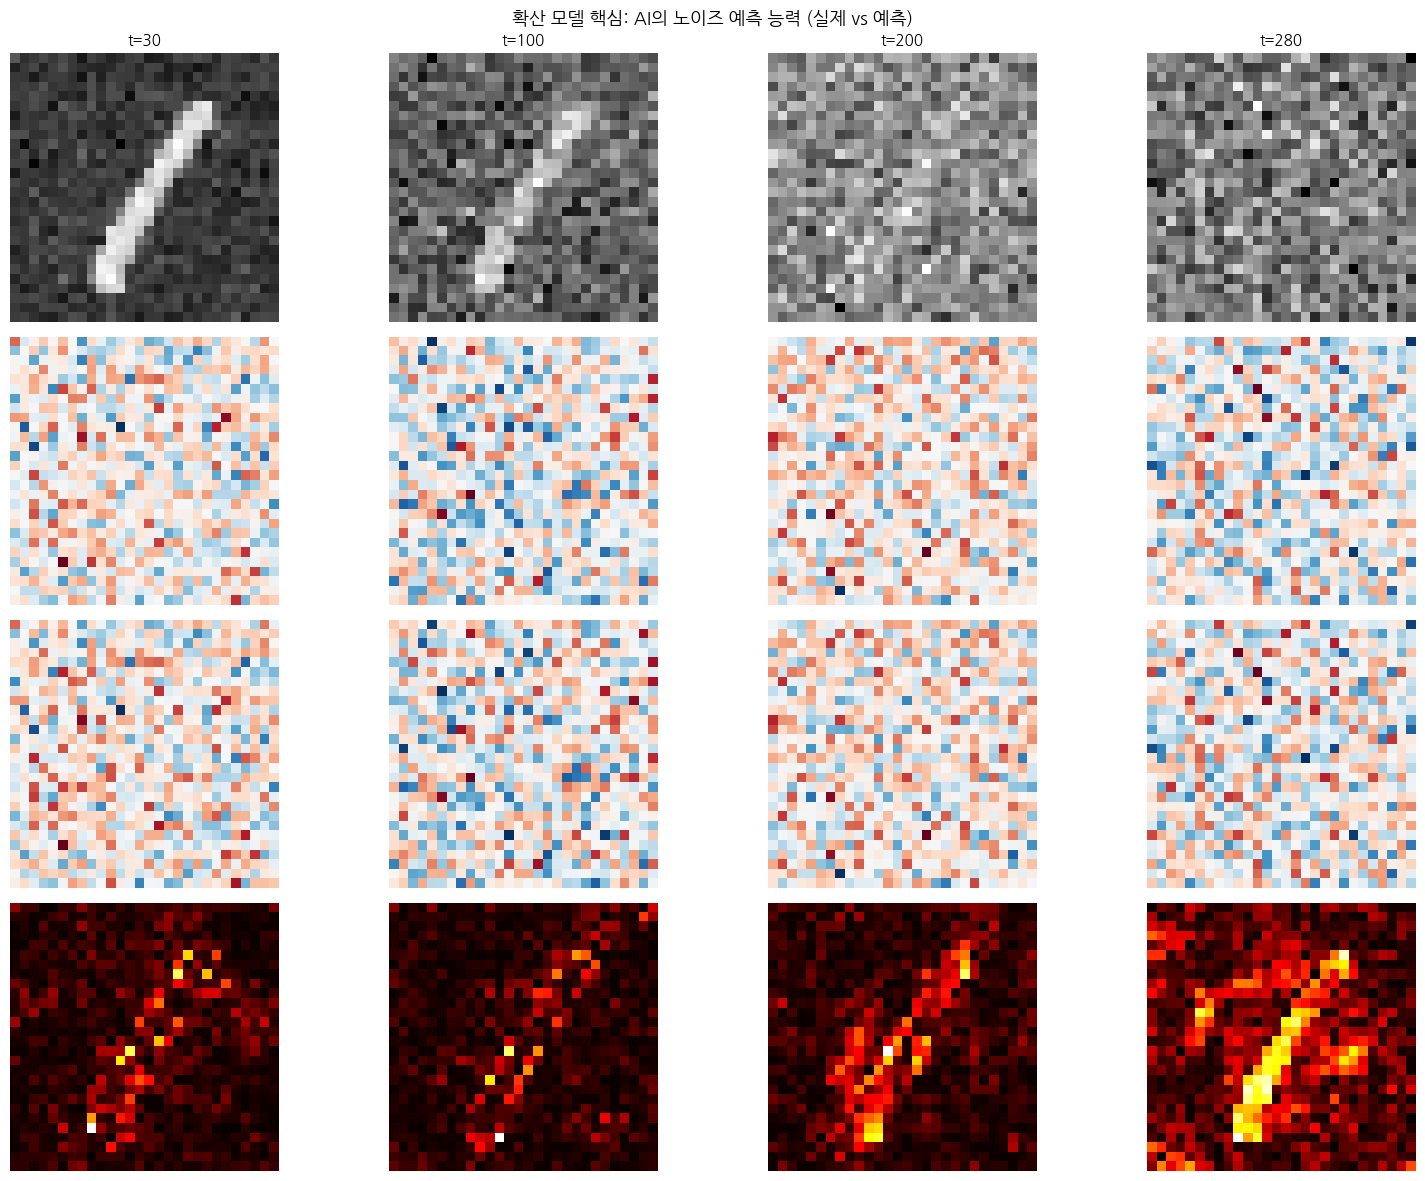

AI가 노이즈를 정확히 예측할수록, 더 깨끗한 이미지를 생성할 수 있습니다.


In [35]:
# AI가 예측한 노이즈 vs 실제 노이즈 비교

noise_pred.eval()
sample_img, label = train_dataset[3]
sample_img = sample_img.unsqueeze(0).to(device)

timesteps_show = [30, 100, 200, 280]
fig, axes = plt.subplots(4, len(timesteps_show), figsize=(16, 12))
row_labels = ['노이즈 추가된 이미지', '실제 노이즈 (정답)', 'AI가 예측한 노이즈', '차이 (밝을수록 오류)']

for col, t in enumerate(timesteps_show):
    t_tensor = torch.tensor([t]).to(device)
    noisy, actual_noise = diffusion.add_noise(sample_img, t_tensor)

    with torch.no_grad():
        pred_noise = noise_pred(noisy, t_tensor)

    axes[0, col].imshow(noisy.cpu().squeeze(), cmap='gray')
    axes[0, col].set_title(f't={t}', fontsize=11, fontweight='bold')
    axes[0, col].axis('off')

    axes[1, col].imshow(actual_noise.cpu().squeeze(), cmap='RdBu_r')
    axes[1, col].axis('off')

    axes[2, col].imshow(pred_noise.cpu().squeeze(), cmap='RdBu_r')
    axes[2, col].axis('off')

    diff = (actual_noise - pred_noise).abs().cpu().squeeze()
    axes[3, col].imshow(diff, cmap='hot')
    axes[3, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=0, labelpad=100, va='center')

plt.suptitle('확산 모델 핵심: AI의 노이즈 예측 능력 (실제 vs 예측)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('AI가 노이즈를 정확히 예측할수록, 더 깨끗한 이미지를 생성할 수 있습니다.')

---
# 📊 전체 비교 및 정리

| 기법 | 핵심 시각화 포인트 |
|------|-------------------|
| **오토인코더** | 784→16 압축 과정, 잠재벡터 패턴 |
| **VAE** | 평균/분산 출력, 같은 입력에서 다른 샘플링, 보간 |
| **GAN** | 노이즈→이미지 변환 레이어, 판별자 점수, 에폭별 성장 |
| **Diffusion** | 순방향 노이즈 추가, 역방향 복원, 노이즈 예측 정확도 |

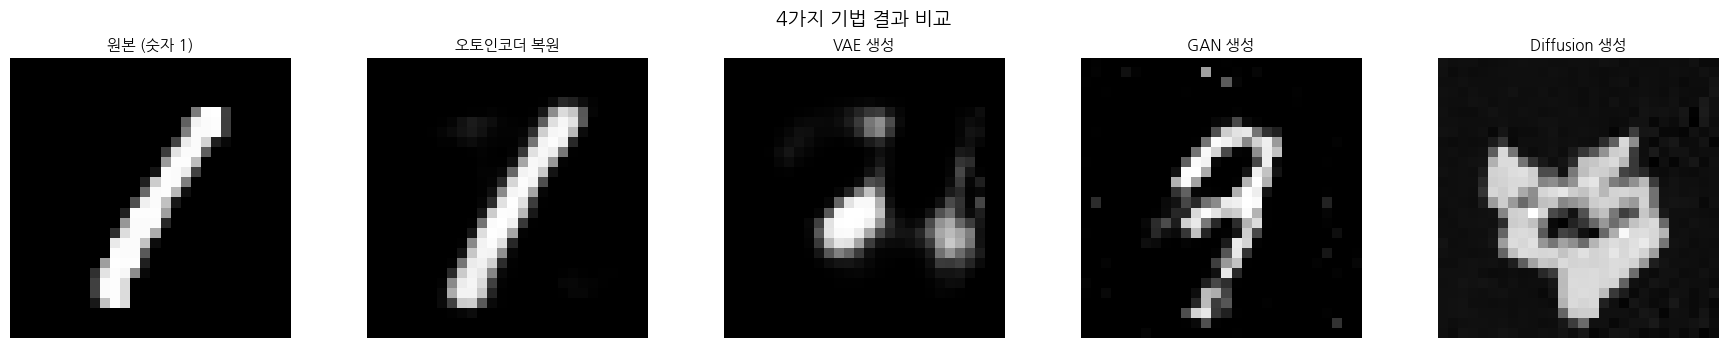


🎓 이미지 생성 AI 기법 학습 완료!


In [36]:
# 4가지 모델 생성 결과 비교

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

# 원본
sample, label = train_dataset[3]
axes[0].imshow(sample.squeeze(), cmap='gray')
axes[0].set_title(f'원본 (숫자 {label})', fontsize=11)
axes[0].axis('off')

# AE 복원
ae_model.eval()
with torch.no_grad():
    ae_out = ae_model(sample.unsqueeze(0).to(device))
axes[1].imshow(ae_out[0].cpu().squeeze(), cmap='gray')
axes[1].set_title('오토인코더 복원', fontsize=11)
axes[1].axis('off')

# VAE 생성
vae_model.eval()
with torch.no_grad():
    z = torch.randn(1, 16).to(device)
    vae_out = vae_model.decode(z)
axes[2].imshow(vae_out[0].cpu().squeeze(), cmap='gray')
axes[2].set_title('VAE 생성', fontsize=11)
axes[2].axis('off')

# GAN 생성
G.eval()
with torch.no_grad():
    z = torch.randn(1, LATENT_DIM).to(device)
    gan_out = G(z)
axes[3].imshow(gan_out[0].cpu().squeeze(), cmap='gray')
axes[3].set_title('GAN 생성', fontsize=11)
axes[3].axis('off')

# Diffusion 생성
axes[4].imshow(generated.cpu().squeeze(), cmap='gray')
axes[4].set_title('Diffusion 생성', fontsize=11)
axes[4].axis('off')

plt.suptitle('4가지 기법 결과 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('\n🎓 이미지 생성 AI 기법 학습 완료!')